# 03 — Orthogonal Four-Basis Decomposition (Z-based)

Demonstrates the full projection workflow on a **real blocking event**
using **geopotential height (Z)** at 500 hPa:

1. Build the orthogonal basis {Φ₁, Φ₂, Φ₃, Φ₄} from Z anomaly and its spatial derivatives
2. Project Z tendency (dZ/dt) onto the basis → (β, αx, αy, γ)
3. Lifecycle time curves by looping over ∆h = −13 … +12

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os, glob
from skimage import measure

from pvtend import (compute_orthogonal_basis, project_field, R_EARTH)
from pvtend.plotting import plot_four_basis, plot_coefficient_curves, plot_field_2d
from pvtend.decomposition.projection import collect_term_fields, ADVECTION_TERMS
from pvtend.decomposition.basis import (
    PRENORM_PHI1, PRENORM_PHI2, PRENORM_PHI3, PRENORM_PHI4,
    gram_schmidt_orthogonalize, OrthogonalBasisFields, weighted_inner_product,
)
from pvtend.decomposition.smoothing import gaussian_smooth_nan

## 1  Load event data and compute Z-based fields

In [2]:
DATA_ROOT = "/net/flood/data2/users/x_yan/composite_blocking_tempest"
CLIM_DIR  = "/net/flood/data2/users/x_yan/era/clim"
STAGE = "onset"
# TRACK_GLOB = "track_873_*"   # 2010 June Russian heatwave
# TRACK_GLOB = "track_566_*"   # 2003 European heatwave 2003071308_dh+0
TRACK_GLOB = "track_425_*"   # gif demo

# Extract track ID for use in lifecycle / budget cells
TRACK_ID = TRACK_GLOB.split("_")[1]   # e.g. "425"

# Smoothing degree used throughout (basis + tendency)
SMOOTH_DEG = 3.0

# ── Pressure level selection ─────────────────────────────────────────
# Always 500 hPa for Z-based decomposition.
LEVEL_HPA = 500

def get_field(dd, key):
    """Extract a 2-D field from the NPZ dict.

    * LEVEL_HPA is None  → use the pre-computed wavg field  (``dd[key]``)
    * LEVEL_HPA is int   → slice from the 3-D array         (``dd[key + '_3d'][level_idx]``)
    """
    if LEVEL_HPA is None:
        return dd[key]
    key_3d = key + "_3d"
    if key_3d in dd:
        levels = dd["levels"]
        idx = np.where(levels == LEVEL_HPA)[0]
        if len(idx) == 0:
            raise ValueError(f"Level {LEVEL_HPA} hPa not in levels={list(levels)}")
        return dd[key_3d][idx[0]]
    return dd[key]   # fallback (field has no 3-D counterpart, e.g. X_rel)

LEVEL_LABEL = f"{LEVEL_HPA} hPa" if LEVEL_HPA is not None else "wavg 300-250-200 hPa"

# ── Monthly-clim Z loading ───────────────────────────────────────────
import calendar
from scipy.interpolate import RegularGridInterpolator
import pandas as pd

_GRAV = 9.80665  # standard gravity (m s⁻²) — clim files store geopotential (m² s⁻²), not gpm

_MONTH_ABBR = {i: calendar.month_abbr[i].lower() for i in range(1, 13)}
_clim_z_cache = {}   # (month,) → xr.Dataset

def _open_clim_z(month: int):
    """Open (and cache) the smoothed monthly Z clim file."""
    if month not in _clim_z_cache:
        abbr = _MONTH_ABBR[month]
        fp = f"{CLIM_DIR}/era5_hourly_clim_1990-2020_{abbr}_z_smooth.nc"
        _clim_z_cache[month] = xr.open_dataset(fp)
        print(f"  Opened clim: {os.path.basename(fp)}")
    return _clim_z_cache[month]


def get_z_clim_patch(timestamp, level_hpa, lat_vec, lon_vec):
    """Return 2-D climatological Z on the NPZ patch grid.

    The clim NC files store **geopotential** (Φ, m² s⁻²).
    We divide by g = 9.80665 to convert to geopotential height (gpm ≡ m).

    Parameters
    ----------
    timestamp : str or datetime-like
        Timestamp from the NPZ file (e.g. '2003-07-17 22:00:00').
    level_hpa : int
        Pressure level in hPa.
    lat_vec, lon_vec : 1-D arrays
        Target patch coordinates (lat ascending/descending, lon in [-180,180] or unwrapped).

    Returns
    -------
    z_clim_2d : ndarray, shape (len(lat_vec), len(lon_vec))
        Geopotential height in gpm (m).
    """
    ts = pd.Timestamp(timestamp)
    ds = _open_clim_z(ts.month)

    # Select day, hour, pressure level from the clim DataArray
    z_da = ds["z"].sel(month=ts.month, day=ts.day, hour=ts.hour,
                       pressure_level=float(level_hpa))
    clim_lat = z_da.coords["latitude"].values   # 90 → 0 (descending)
    clim_lon = z_da.coords["longitude"].values   # -180 → 178.5
    z_vals = z_da.values / _GRAV  # geopotential → geopotential height (gpm)

    # Build interpolator (need ascending axes)
    lat_asc = clim_lat[::-1]
    z_asc   = z_vals[::-1, :]
    interp = RegularGridInterpolator(
        (lat_asc, clim_lon), z_asc,
        method="linear", bounds_error=False, fill_value=None,
    )

    # Map target lon into clim range [-180, 178.5]
    lon_target = ((np.asarray(lon_vec, dtype=float) + 180.0) % 360.0) - 180.0
    lat_target = np.asarray(lat_vec, dtype=float)
    lon2d, lat2d = np.meshgrid(lon_target, lat_target)
    pts = np.column_stack([lat2d.ravel(), lon2d.ravel()])
    z_clim_2d = interp(pts).reshape(len(lat_target), len(lon_target))
    return z_clim_2d


# ── Z-based derivative helpers (clim-based anomaly, adaptive prenorm) ─

def compute_z_derivs(z_2d, x_rel, y_rel, center_lat, z_clim_2d=None):
    """Compute Z anomaly and spatial derivatives on the relative grid.

    Parameters
    ----------
    z_2d : 2-D array  – raw Z field on the patch (gpm).
    z_clim_2d : 2-D array or None
        If provided, anomaly = z_2d - z_clim_2d.
        If None, falls back to domain mean.

    Returns (z_anom, z_dx, z_dy, z_dx_dy) in physical units.
    """
    dx_deg = float(x_rel[1] - x_rel[0])
    dy_deg = float(y_rel[1] - y_rel[0])
    cos_lat = np.cos(np.radians(center_lat))
    dx_m = dx_deg * np.pi / 180.0 * R_EARTH * cos_lat
    dy_m = dy_deg * np.pi / 180.0 * R_EARTH

    if z_clim_2d is not None:
        z_anom = z_2d - z_clim_2d
    else:
        z_anom = z_2d - np.nanmean(z_2d)

    z_dx   = np.gradient(z_anom, dx_m, axis=1)
    z_dy   = np.gradient(z_anom, dy_m, axis=0)
    z_dxdy = np.gradient(z_dx,  dy_m, axis=0)
    return z_anom, z_dx, z_dy, z_dxdy


def _adaptive_prenorm(arr):
    """Return a scalar that brings |arr| to O(1).

    Uses 1 / RMS(arr) so that the pre-normalized field has RMS ≈ 1.
    """
    rms = np.sqrt(np.nanmean(arr ** 2))
    if rms < 1e-30:
        return 1.0
    return 1.0 / rms


def build_z_basis(z_2d, x_rel, y_rel, center_lat,
                  smooth_deg=3.0, grid_spacing=1.5, z_clim_2d=None):
    """Build 4 orthogonal basis fields from Z at a single time step.

    Pipeline: compute derivs → adaptive prenorm → smooth → mask (z_anom > 0)
              → Gram-Schmidt.
    Returns an OrthogonalBasisFields container.
    """
    z_anom, z_dx, z_dy, z_dxdy = compute_z_derivs(
        z_2d, x_rel, y_rel, center_lat, z_clim_2d=z_clim_2d)

    # Adaptive pre-normalization: bring each field to RMS ≈ 1
    pn1 = _adaptive_prenorm(z_anom)
    pn2 = _adaptive_prenorm(z_dx)
    pn3 = _adaptive_prenorm(z_dy)
    pn4 = _adaptive_prenorm(z_dxdy)

    phi1 = z_anom * pn1
    phi2 = z_dx   * pn2
    phi3 = z_dy   * pn3
    phi4 = z_dxdy * pn4

    # Smooth
    fields = [gaussian_smooth_nan(f, smooth_deg, grid_spacing)
              for f in [phi1, phi2, phi3, phi4]]

    # Mask: finite values AND z_anom > 0 (blocking = positive Z anomaly)
    mask = np.ones_like(fields[0], dtype=bool)
    for f in fields:
        mask &= np.isfinite(f)
    # Use the smoothed z_anom (phi1) for the sign mask to be consistent
    # with the smoothed basis fields
    mask &= (fields[0] > 0)

    X_grid, Y_grid = np.meshgrid(x_rel, y_rel)
    weights = np.where(mask, 1.0, 0.0)

    # Gram-Schmidt orthogonalization
    ortho, norms = gram_schmidt_orthogonalize(fields, weights, mask)

    prenorm_dict = {"beta": pn1, "ax": pn2, "ay": pn3, "gamma": pn4}
    norms_dict   = {"beta": norms[0], "ax": norms[1],
                    "ay": norms[2], "gamma": norms[3]}

    return OrthogonalBasisFields(
        phi_int=np.asarray(ortho[0], dtype=float),
        phi_dx =np.asarray(ortho[1], dtype=float),
        phi_dy =np.asarray(ortho[2], dtype=float),
        phi_def=np.asarray(ortho[3], dtype=float),
        weights=weights, mask=mask,
        x_rel=np.asarray(x_rel, dtype=float),
        y_rel=np.asarray(y_rel, dtype=float),
        Y_grid=Y_grid,
        raw_phi_int=z_anom, raw_phi_dx=z_dx,
        raw_phi_dy=z_dy, raw_phi_def=z_dxdy,
        norms=norms_dict, scale_factors=prenorm_dict,
    )


# ── Load dh=0 and dh=-1 via glob (universal) ────────────────────────
_files_0  = sorted(glob.glob(f"{DATA_ROOT}/{STAGE}/dh=+0/{TRACK_GLOB}.npz"))
_files_m1 = sorted(glob.glob(f"{DATA_ROOT}/{STAGE}/dh=-1/{TRACK_GLOB}.npz"))
assert _files_0,  f"No dh=+0 files for pattern {TRACK_GLOB}"
assert _files_m1, f"No dh=-1 files for pattern {TRACK_GLOB}"

d0  = dict(np.load(_files_0[0]))
dm1 = dict(np.load(_files_m1[0]))
X_rel = d0["X_rel"]
Y_rel = d0["Y_rel"]
x_rel = X_rel[0, :]    # 1D
y_rel = Y_rel[:, 0]
clat0 = float(d0["center_lat"])

# ── Compute Z fields at dh=0 and dh=-1 with monthly clim ────────────
z0_2d  = get_field(d0,  "z")
zm1_2d = get_field(dm1, "z")

# Get climatological Z for each timestep
z_clim_0  = get_z_clim_patch(str(d0["ts"]),  LEVEL_HPA,
                              d0["lat_vec"],  d0["lon_vec_unwrapped"])
z_clim_m1 = get_z_clim_patch(str(dm1["ts"]), LEVEL_HPA,
                              dm1["lat_vec"], dm1["lon_vec_unwrapped"])

z_dt_0 = (z0_2d - zm1_2d) / 3600.0   # dZ/dt (gpm/s, forward diff)

z_anom_0,  _, _, _ = compute_z_derivs(z0_2d,  x_rel, y_rel, clat0,
                                       z_clim_2d=z_clim_0)
z_anom_m1, _, _, _ = compute_z_derivs(zm1_2d, x_rel, y_rel, clat0,
                                       z_clim_2d=z_clim_m1)

print(f"Loaded dh=+0 : {os.path.basename(_files_0[0])}")
print(f"Loaded dh=-1 : {os.path.basename(_files_m1[0])}")
print(f"Patch shape  : {X_rel.shape}")
print(f"Level        : {LEVEL_LABEL}")
print(f"Z500 range (dh=0)  : {z0_2d.min():.0f} – {z0_2d.max():.0f} gpm")
print(f"Z clim range (dh=0): {z_clim_0.min():.0f} – {z_clim_0.max():.0f} gpm")
print(f"Z_anom range        : {z_anom_0.min():.0f} – {z_anom_0.max():.0f} gpm")
print(f"dZ/dt RMS           : {np.sqrt(np.nanmean(z_dt_0**2)):.4f} gpm/s")

  Opened clim: era5_hourly_clim_1990-2020_jan_z_smooth.nc
Loaded dh=+0 : track_425_2000011120_dh+0.npz
Loaded dh=-1 : track_425_2000011119_dh-1.npz
Patch shape  : (29, 49)
Level        : 500 hPa
Z500 range (dh=0)  : 4797 – 5799 gpm
Z clim range (dh=0): 5086 – 5763 gpm
Z_anom range        : -333 – 173 gpm
dZ/dt RMS           : 0.0023 gpm/s


## 2  Build orthogonal basis from Z at dh = −1

In [3]:
# Build basis from dh=-1 (predictive framing: project tendency at t onto prior pattern)
basis = build_z_basis(zm1_2d, x_rel, y_rel, clat0,
                      smooth_deg=SMOOTH_DEG, grid_spacing=1.5,
                      z_clim_2d=z_clim_m1)
print("Basis norms :", {k: f"{v:.4e}" for k, v in basis.norms.items()})
print("Scale factors:", {k: f"{v:.4e}" for k, v in basis.scale_factors.items()})

Basis norms : {'beta': '2.3504e+02', 'ax': '4.2283e+02', 'ay': '2.5989e+02', 'gamma': '3.4280e+02'}
Scale factors: {'beta': '7.8189e-03', 'ax': '6.3915e+03', 'ay': '7.6647e+03', 'gamma': '4.5119e+09'}


## 3  Visualise the four Z-basis fields

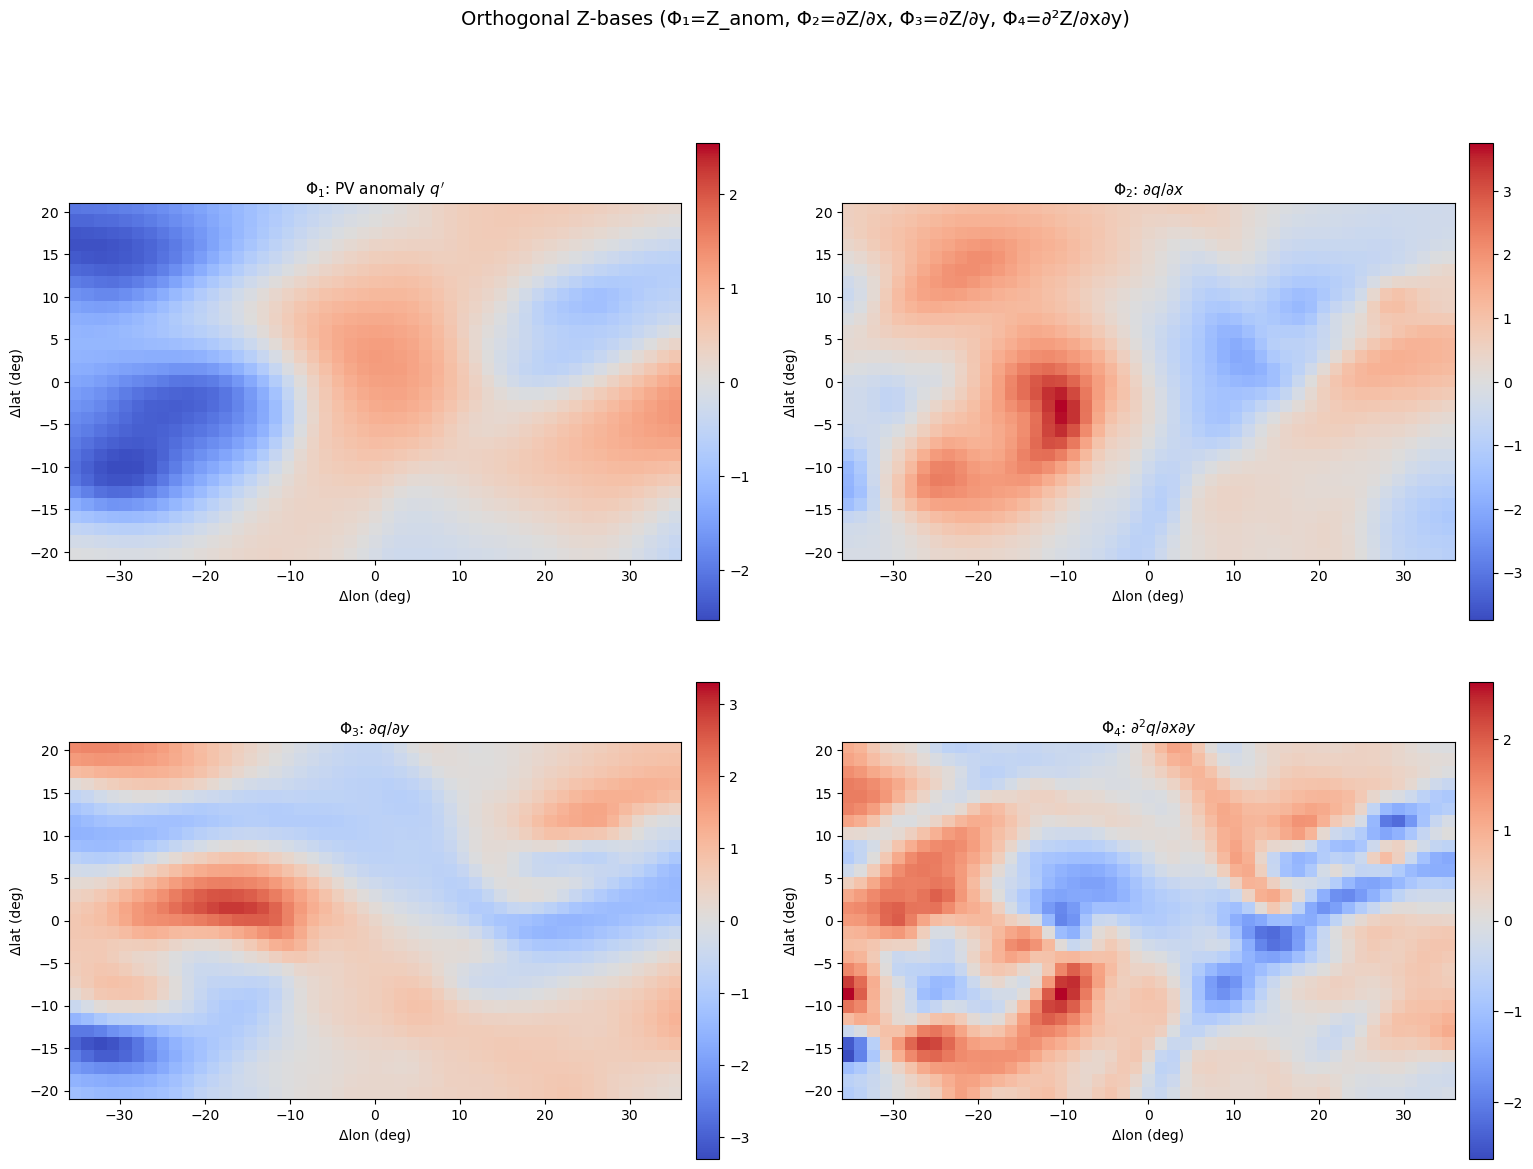

In [4]:
fig = plot_four_basis(
    basis.phi_int, basis.phi_dx, basis.phi_dy, basis.phi_def,
    x_rel, y_rel,
    suptitle="Orthogonal Z-bases (Φ₁=Z_anom, Φ₂=∂Z/∂x, Φ₃=∂Z/∂y, Φ₄=∂²Z/∂x∂y)",
)
plt.show()

## 4  Project dZ/dt onto basis

In [5]:
z_dt_smooth = gaussian_smooth_nan(z_dt_0, smoothing_deg=SMOOTH_DEG, grid_spacing=1.5)

proj = project_field(z_dt_smooth, basis)

print(f"Level: {LEVEL_LABEL}")
print(f"β  (intensification)   = {proj['beta']:.3e}  s⁻¹")
print(f"αx (zonal propagation) = {proj['ax']:.3f}  m/s")
print(f"αy (merid. propagation) = {proj['ay']:.3f}  m/s")
print(f"γ  (deformation)       = {proj['gamma']:.3e}  m² s⁻¹")
print(f"RMSE / max|dZ/dt|      = {proj['rmse'] / (np.nanmax(np.abs(z_dt_smooth)) + 1e-30):.3f}")

Level: 500 hPa
β  (intensification)   = 1.509e-05  s⁻¹
αx (zonal propagation) = 11.564  m/s
αy (merid. propagation) = 5.695  m/s
γ  (deformation)       = -1.649e+05  m² s⁻¹
RMSE / max|dZ/dt|      = 0.189


## 5  2-D component maps (Z-based)

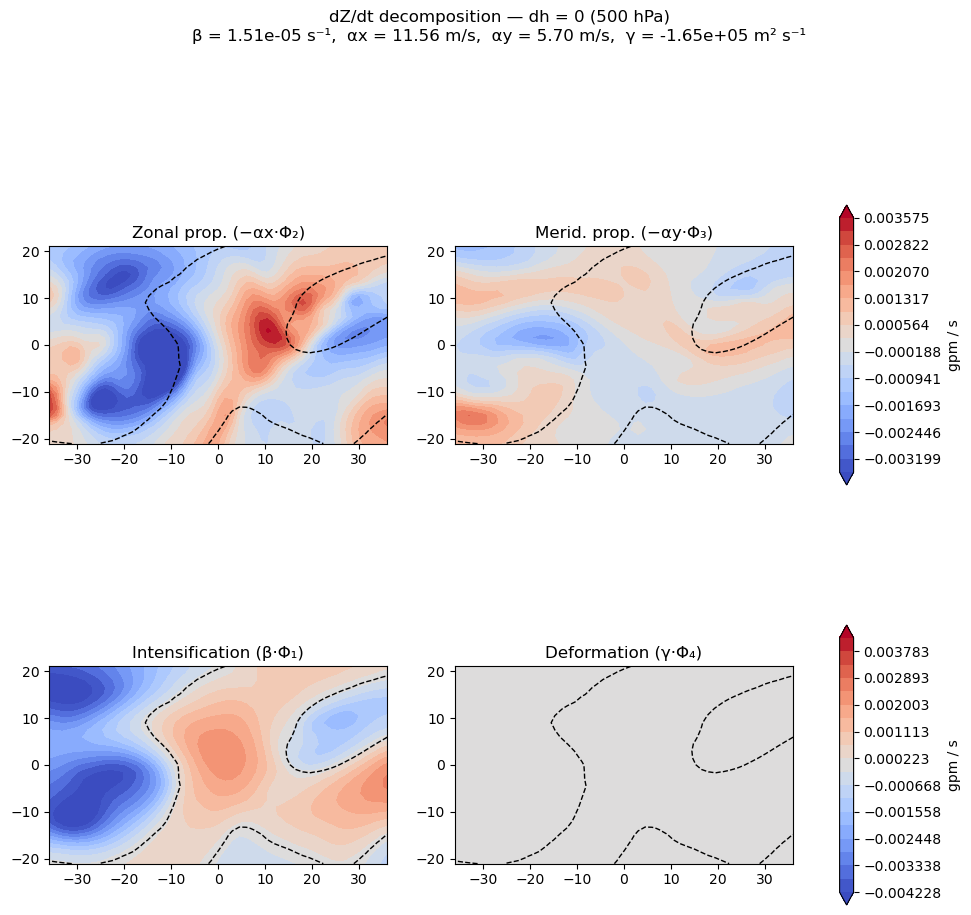

In [6]:
# Reconstruct individual components manually
beta_comp  = proj["beta_raw"]  * basis.phi_int
ax_comp    = -proj["ax_raw"]   * basis.phi_dx
ay_comp    = -proj["ay_raw"]   * basis.phi_dy
gamma_comp = proj["gamma_raw"] * basis.phi_def

# Separate vmax for each row
vmax_prop = max(np.nanpercentile(np.abs(ax_comp), 95),
                np.nanpercentile(np.abs(ay_comp), 95))
vmax_id   = max(np.nanpercentile(np.abs(beta_comp), 95),
                np.nanpercentile(np.abs(gamma_comp), 95))
levels_prop = np.linspace(-vmax_prop, vmax_prop, 20)
levels_id   = np.linspace(-vmax_id,   vmax_id,   20)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Row 1: propagation (ax, ay) — shared colorbar ---
for i, (comp, title) in enumerate([
    (ax_comp,  "Zonal prop. (−αx·Φ₂)"),
    (ay_comp,  "Merid. prop. (−αy·Φ₃)"),
]):
    a = axes[0, i]
    cf_prop = a.contourf(x_rel, y_rel, comp, levels=levels_prop,
                         cmap="coolwarm", extend="both")
    a.contour(x_rel, y_rel, z_anom_0, levels=[0],
              colors="k", linewidths=1.0, linestyles="--")
    a.set_title(title)
    a.set_aspect("equal")
fig.colorbar(cf_prop, ax=axes[0, :].tolist(), shrink=0.8, label="gpm / s")

# --- Row 2: intensification & deformation — shared colorbar ---
for i, (comp, title) in enumerate([
    (beta_comp,  "Intensification (β·Φ₁)"),
    (gamma_comp, "Deformation (γ·Φ₄)"),
]):
    a = axes[1, i]
    cf_id = a.contourf(x_rel, y_rel, comp, levels=levels_id,
                       cmap="coolwarm", extend="both")
    a.contour(x_rel, y_rel, z_anom_0, levels=[0],
              colors="k", linewidths=1.0, linestyles="--")
    a.set_title(title)
    a.set_aspect("equal")
fig.colorbar(cf_id, ax=axes[1, :].tolist(), shrink=0.8, label="gpm / s")

subtitle = (
    f"β = {proj['beta']:.2e} s⁻¹,  "
    f"αx = {proj['ax']:.2f} m/s,  "
    f"αy = {proj['ay']:.2f} m/s,  "
    f"γ = {proj['gamma']:.2e} m² s⁻¹"
)
fig.suptitle(f"dZ/dt decomposition — dh = 0 ({LEVEL_LABEL})\n" + subtitle, y=1.04, fontsize=12)
plt.show()

## 5b  Original vs. Reconstructed dZ/dt

Level used: 500 hPa

Reconstruction quality:
  RMSE             = 1.228e-03
  RMSE / max|dZ/dt| = 0.189
  Correlation       = 0.5360


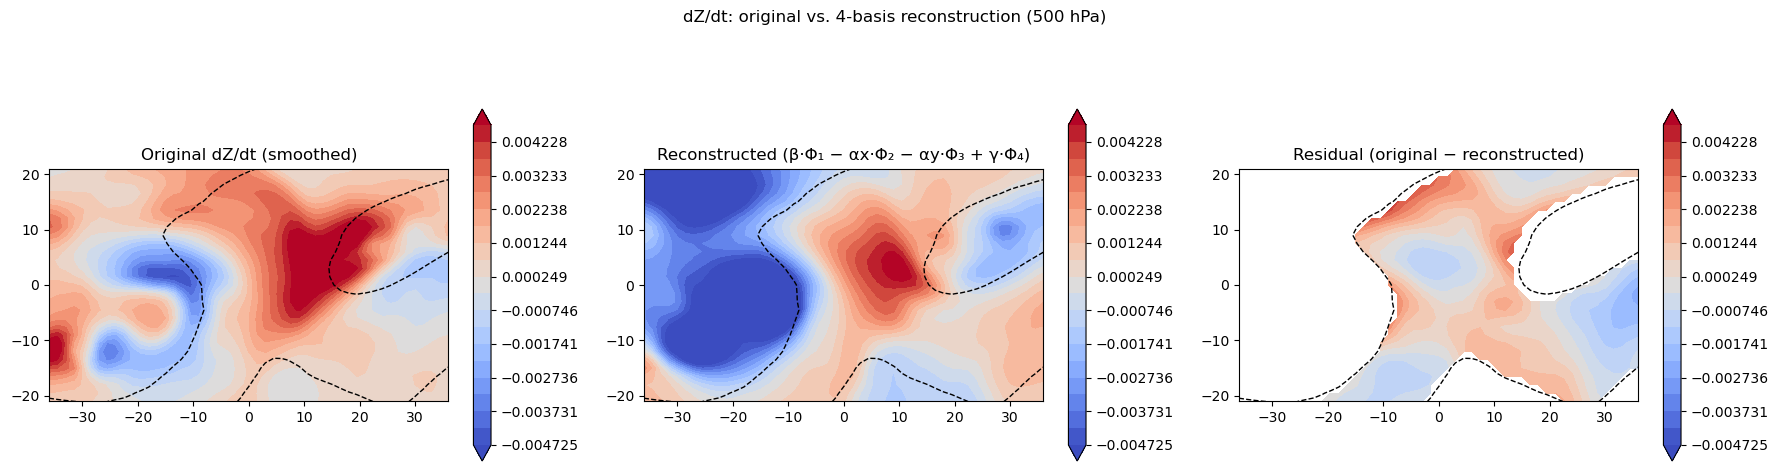

In [7]:
# Original (smoothed) vs. reconstructed dZ/dt
recon = proj["recon"]
resid = proj["resid"]

vmax = np.nanpercentile(np.abs(z_dt_smooth), 95)
levels_cf = np.linspace(-vmax, vmax, 20)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Original ---
cf0 = axes[0].contourf(x_rel, y_rel, z_dt_smooth,
                        levels=levels_cf, cmap="coolwarm", extend="both")
axes[0].contour(x_rel, y_rel, z_anom_0, levels=[0],
                colors="k", linewidths=1.0, linestyles="--")
axes[0].set_title("Original dZ/dt (smoothed)")
axes[0].set_aspect("equal")
plt.colorbar(cf0, ax=axes[0], shrink=0.8)

# --- Reconstructed ---
cf1 = axes[1].contourf(x_rel, y_rel, recon,
                        levels=levels_cf, cmap="coolwarm", extend="both")
axes[1].contour(x_rel, y_rel, z_anom_0, levels=[0],
                colors="k", linewidths=1.0, linestyles="--")
axes[1].set_title("Reconstructed (β·Φ₁ − αx·Φ₂ − αy·Φ₃ + γ·Φ₄)")
axes[1].set_aspect("equal")
plt.colorbar(cf1, ax=axes[1], shrink=0.8)

# --- Residual ---
cf2 = axes[2].contourf(x_rel, y_rel, resid,
                        levels=levels_cf, cmap="coolwarm", extend="both")
axes[2].contour(x_rel, y_rel, z_anom_0, levels=[0],
                colors="k", linewidths=1.0, linestyles="--")
axes[2].set_title("Residual (original − reconstructed)")
axes[2].set_aspect("equal")
plt.colorbar(cf2, ax=axes[2], shrink=0.8)

print(f"Level used: {LEVEL_LABEL}")
print(f"\nReconstruction quality:")
print(f"  RMSE             = {proj['rmse']:.3e}")
print(f"  RMSE / max|dZ/dt| = {proj['rmse'] / (np.nanmax(np.abs(z_dt_smooth)) + 1e-30):.3f}")
valid = np.isfinite(z_dt_smooth) & np.isfinite(recon)
print(f"  Correlation       = {np.corrcoef(z_dt_smooth[valid], recon[valid])[0,1]:.4f}")

fig.suptitle(f"dZ/dt: original vs. 4-basis reconstruction ({LEVEL_LABEL})", y=1.02)
fig.tight_layout()
plt.show()

## 6  Lifecycle time curves — Z-based (dh = −13 … +12)

In [8]:
import os, glob

dh_values = list(range(-13, 13))
coefs = {k: [] for k in ["beta", "ax", "ay", "gamma"]}

for dh in dh_values:
    sign = "+" if dh >= 0 else ""
    pattern = f"{DATA_ROOT}/{STAGE}/dh={sign}{dh}/track_{TRACK_ID}_*_dh{sign}{dh}.npz"
    files = sorted(glob.glob(pattern))
    if not files:
        for k in coefs:
            coefs[k].append(np.nan)
        continue

    dd = dict(np.load(files[0]))

    # For z_dt we need the previous timestep
    dh_prev = max(dh - 1, -13)
    sign_p = "+" if dh_prev >= 0 else ""
    pat_p = f"{DATA_ROOT}/{STAGE}/dh={sign_p}{dh_prev}/track_{TRACK_ID}_*_dh{sign_p}{dh_prev}.npz"
    fp = sorted(glob.glob(pat_p))
    dp = dict(np.load(fp[0])) if fp else dd

    z_curr = get_field(dd, "z")
    z_prev = get_field(dp, "z")
    z_dt_loc = (z_curr - z_prev) / 3600.0
    clat_loc = float(dd["center_lat"])

    # Load clim Z for the basis timestep (dh-1)
    z_clim_prev = get_z_clim_patch(
        str(dp["ts"]), LEVEL_HPA, dp["lat_vec"], dp["lon_vec_unwrapped"])

    # Build Z basis from dh-1 (predictive framing) with clim anomaly
    b = build_z_basis(z_prev, x_rel, y_rel, clat_loc,
                      smooth_deg=SMOOTH_DEG, grid_spacing=1.5,
                      z_clim_2d=z_clim_prev)
    z_dt_s = gaussian_smooth_nan(z_dt_loc, smoothing_deg=SMOOTH_DEG, grid_spacing=1.5)
    p = project_field(z_dt_s, b)
    for k in coefs:
        coefs[k].append(p[k])

# Convert to arrays
for k in coefs:
    coefs[k] = np.array(coefs[k])

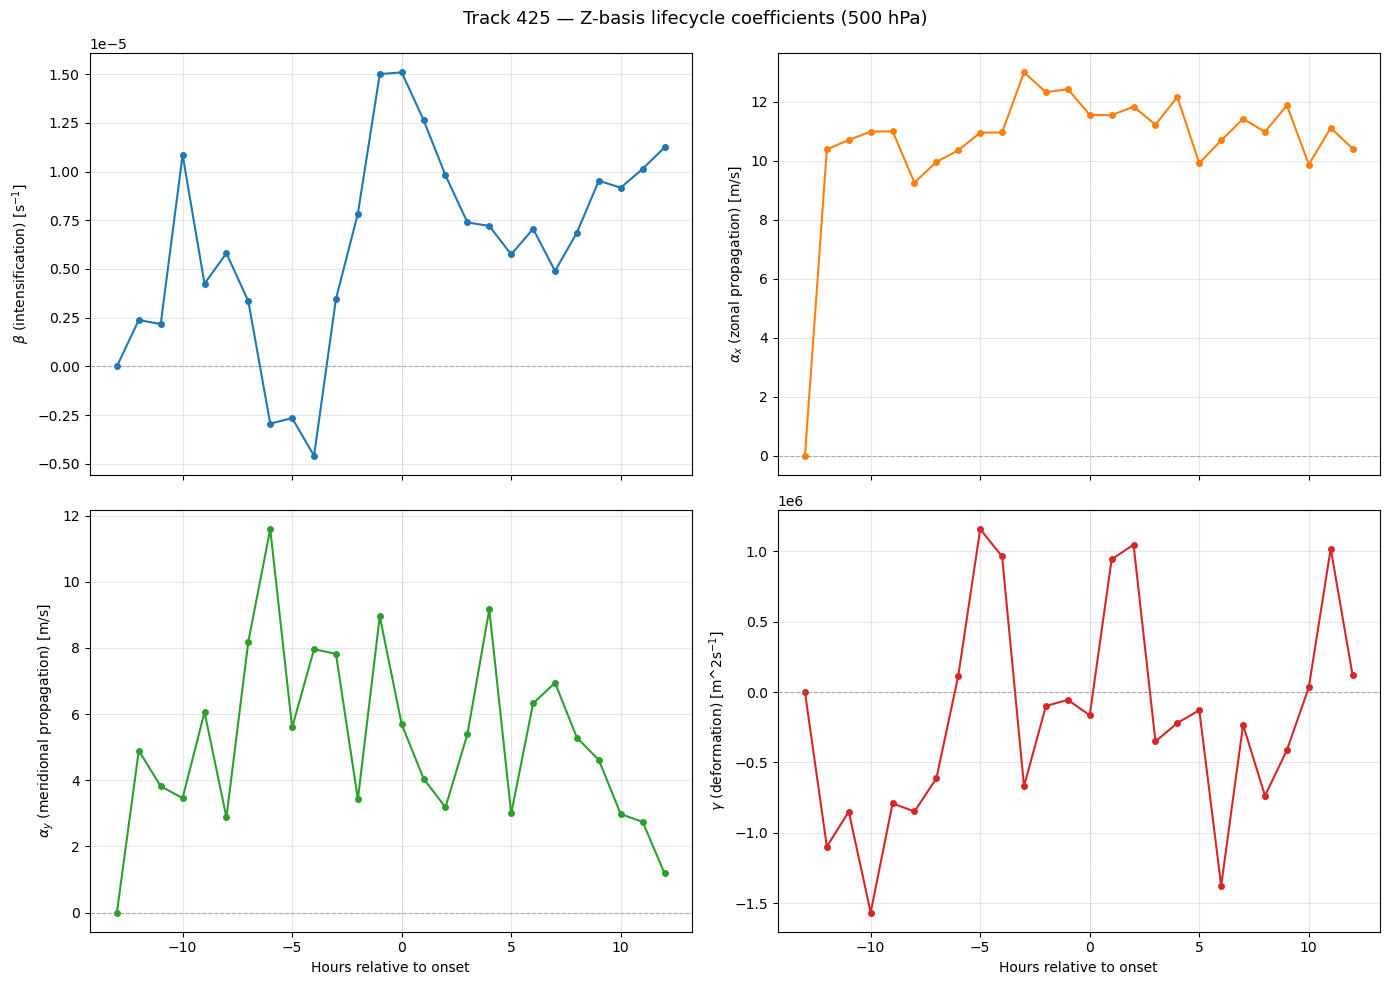

In [9]:
fig = plot_coefficient_curves(
    np.array(dh_values),
    coefs,
    title=f"Track {TRACK_ID} — Z-basis lifecycle coefficients ({LEVEL_LABEL})",
    xlabel="Hours relative to onset",
)
plt.show()

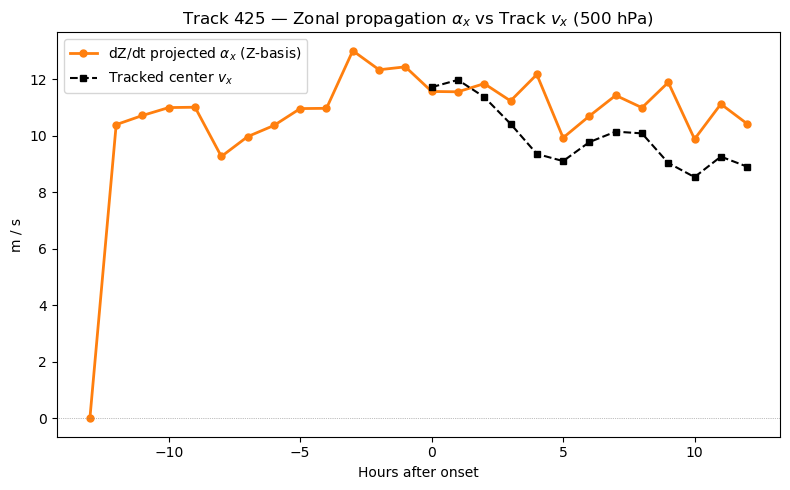

In [10]:
# ── Overlay diagnosed αx with tracking-centre zonal velocity ─────────

import re
from datetime import datetime, timedelta

# ── 1. Parse track centres for this track from blockstats ────────────
BLOCKSTATS = "/net/flood/data2/users/x_yan/tracking_tmpp/ERA5_blockstats.txt"
BLOCKID_DIR = "/net/flood/data2/users/x_yan/tracking_tmpp/blockids_full"

track_rows = []
with open(BLOCKSTATS) as fh:
    for line in fh:
        parts = line.strip().split("\t")
        if parts[0].strip() == TRACK_ID:
            track_rows.append(parts)

# Build arrays: timestamps, lat, lon
_ts_list, _lat_list, _lon_list = [], [], []
for row in track_rows:
    ts_str = row[2].strip().strip('"')
    _ts_list.append(datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S"))
    _lat_list.append(float(row[3].strip()))
    _lon_list.append(float(row[4].strip()))

ts_arr = np.array(_ts_list)
lat_arr = np.array(_lat_list)
lon_arr = np.array(_lon_list)

# ── 2. Compute track-centre velocity (m/s) via centred differences ───
cos_lat = np.cos(np.radians(lat_arr))
dlat = np.gradient(lat_arr)          # deg/hour (Δt = 1 h)
dlon = np.gradient(lon_arr)          # deg/hour
vx_track = dlon * (np.pi / 180.0) * R_EARTH * cos_lat / 3600.0   # m/s
vy_track = dlat * (np.pi / 180.0) * R_EARTH / 3600.0             # m/s

# ── 3. Identify onset timestamp and map dh → track index ─────────────
onset_ts = datetime.strptime(str(d0["ts"]), "%Y-%m-%d %H:%M:%S")
dh_hours = np.array(dh_values)

# Map each dh to the corresponding track index (all dh, including negative)
track_vx_at_dh = np.full_like(dh_hours, np.nan, dtype=float)
track_vy_at_dh = np.full_like(dh_hours, np.nan, dtype=float)
for i, dh in enumerate(dh_hours):
    target_ts = onset_ts + timedelta(hours=int(dh))
    matches = np.where(ts_arr == target_ts)[0]
    if len(matches) == 1:
        idx = matches[0]
        track_vx_at_dh[i] = vx_track[idx]
        track_vy_at_dh[i] = vy_track[idx]

# ── 4. Single panel: αx vs track vx ─────────────────────────────────
mask = dh_hours >= -20
dh_pos = dh_hours[mask]
ax_pos = coefs["ax"][mask]
vx_pos = track_vx_at_dh[mask]

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(dh_pos, ax_pos, "C1-o", ms=5, lw=2,
         label=r"dZ/dt projected $\alpha_x$ (Z-basis)")
ax1.plot(dh_pos, vx_pos, "k--s", ms=5, lw=1.5, label="Tracked center $v_x$")
ax1.axhline(0, color="grey", lw=0.5, ls=":")
ax1.set_xlabel("Hours after onset")
ax1.set_ylabel("m / s")
ax1.set_title(rf"Track {TRACK_ID} — Zonal propagation $\alpha_x$ vs Track $v_x$ ({LEVEL_LABEL})",
              fontsize=12)
ax1.legend(fontsize=10)
fig.tight_layout()
plt.show()

In [11]:
# ── Animated GIF: Z tracking (cartopy) + basis decomposition ─────────
# Left : total Z shading on rectangular PlateCarree map
#        + z_anom contour + tracked contour shape from blockid NC
#        + track centre trajectory from blockstats (all dh)
# Right: 2 cols × 4 rows
#   col-1 = β, αx, αy, γ 1D lifecycle curve with units
#   col-2 = coef × Φ̂_i  2D field (αx, αy NEGATED) + semi-transparent z_anom contour

import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image as IPImage
from pvtend.decomposition.smoothing import gaussian_smooth_nan
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import timedelta
from pathlib import Path
import pandas as pd

GIF_PATH = "/net/flood/data2/users/x_yan/tmp/track_{}_z_lifecycle.gif".format(TRACK_ID)

# ── Helper: extract tracked feature boundary from blockid NC ─────────
def _lon_to_180(lon):
    return ((lon + 180.0) % 360.0) - 180.0

def get_feature_boundary(blockid_cache, track_id, timestamp):
    """Return list of (lons, lats) contour polygons for a tracked feature."""
    ts_pd = pd.Timestamp(timestamp)
    key = (ts_pd.year, ts_pd.month)
    if key not in blockid_cache:
        return []
    ds = blockid_cache[key]
    try:
        time_idx = np.where(pd.to_datetime(ds["time"].values) == ts_pd)[0]
        if len(time_idx) == 0:
            return []
        time_idx = time_idx[0]
    except Exception:
        return []
    obj_id = ds["object_id"].isel(time=time_idx).values
    lat = ds["latitude"].values
    lon = ds["longitude"].values
    mask = (obj_id == int(track_id)).astype(float)
    if mask.sum() == 0:
        return []
    try:
        contours = measure.find_contours(mask, 0.5)
    except Exception:
        return []
    boundaries = []
    for contour in contours:
        lat_vals = np.interp(contour[:, 0], np.arange(len(lat)), lat)
        lon_vals = np.interp(contour[:, 1], np.arange(len(lon)), lon)
        lon_vals = _lon_to_180(lon_vals)
        boundaries.append((lon_vals, lat_vals))
    return boundaries

# ── Preload blockid NC files for relevant months ─────────────────────
def load_blockid_cache(blockid_dir, timestamps):
    unique_months = set()
    for ts in timestamps:
        ts_pd = pd.Timestamp(ts)
        unique_months.add((ts_pd.year, ts_pd.month))
    cache = {}
    for year, month in sorted(unique_months):
        fp = Path(blockid_dir) / f"era5_z_{year}_{month:02d}_blockid.nc"
        if fp.exists():
            cache[(year, month)] = xr.open_dataset(fp)
            print(f"  Loaded blockid: {fp.name}")
        else:
            print(f"  Warning: blockid not found: {fp}")
    return cache

# ── Pre-load all dh frames (Z-based) ────────────────────────────────
frames_data = {}
frame_timestamps = []
for dh in dh_values:
    sign = "+" if dh >= 0 else ""
    pattern = f"{DATA_ROOT}/{STAGE}/dh={sign}{dh}/track_{TRACK_ID}_*_dh{sign}{dh}.npz"
    files = sorted(glob.glob(pattern))
    if not files:
        continue
    dd = dict(np.load(files[0]))

    # Basis from dh-1
    dh_basis = max(dh - 1, -13)
    sign_b = "+" if dh_basis >= 0 else ""
    pat_b = f"{DATA_ROOT}/{STAGE}/dh={sign_b}{dh_basis}/track_{TRACK_ID}_*_dh{sign_b}{dh_basis}.npz"
    fb = sorted(glob.glob(pat_b))
    db = dict(np.load(fb[0])) if fb else dd

    z_curr = get_field(dd, "z")
    z_prev = get_field(db, "z")
    z_dt_loc = (z_curr - z_prev) / 3600.0
    clat_loc = float(dd["center_lat"])

    # Load clim Z for the basis timestep
    z_clim_prev = get_z_clim_patch(
        str(db["ts"]), LEVEL_HPA, db["lat_vec"], db["lon_vec_unwrapped"])

    basis = build_z_basis(z_prev, x_rel, y_rel, clat_loc,
                          smooth_deg=SMOOTH_DEG, grid_spacing=1.5,
                          z_clim_2d=z_clim_prev)
    z_dt_s = gaussian_smooth_nan(z_dt_loc, smoothing_deg=SMOOTH_DEG, grid_spacing=1.5)
    proj = project_field(z_dt_s, basis)

    # Compute z_anom at current time for contour overlay
    z_clim_curr = get_z_clim_patch(
        str(dd["ts"]), LEVEL_HPA, dd["lat_vec"], dd["lon_vec_unwrapped"])
    z_anom_curr = z_curr - z_clim_curr

    frame_ts = str(dd["ts"])
    frame_timestamps.append(frame_ts)

    frames_data[dh] = {
        "z_total": z_curr,
        "z_anom": z_anom_curr,
        "center_lat": float(dd["center_lat"]),
        "center_lon": float(dd["center_lon"]),
        "lat_vec": dd["lat_vec"],
        "lon_vec": dd["lon_vec_unwrapped"],
        "basis": basis,
        "proj": proj,
        "ts": frame_ts,
    }

dh_avail = sorted(frames_data.keys())
print(f"Loaded {len(dh_avail)} frames: dh = {dh_avail[0]} … {dh_avail[-1]}")

# ── Load blockid cache for tracked contour shapes ────────────────────
print("Loading blockid cache for tracked contour shapes...")
blockid_cache = load_blockid_cache(BLOCKID_DIR, frame_timestamps)

# ── Track trajectory from blockstats (ALL dh, including negative) ────
# ts_arr, lat_arr, lon_arr, onset_ts already parsed in cell 18
traj_txt_lats = {}   # dh -> lat
traj_txt_lons = {}   # dh -> lon
for dh in dh_avail:
    target_ts = onset_ts + timedelta(hours=int(dh))
    matches = np.where(ts_arr == target_ts)[0]
    if len(matches) == 1:
        traj_txt_lats[dh] = lat_arr[matches[0]]
        traj_txt_lons[dh] = lon_arr[matches[0]]

print(f"Track trajectory points: {len(traj_txt_lats)} (from dh={min(traj_txt_lats.keys(), default='?')} to dh={max(traj_txt_lats.keys(), default='?')})")

# ── Precompute global colour limits ─────────────────────────────────
all_z = np.concatenate([frames_data[dh]["z_total"].ravel() for dh in dh_avail])
z_vmin, z_vmax = np.nanpercentile(all_z, [2, 98])

coef_keys = ["beta", "ax", "ay", "gamma"]
# Sign convention for 2D maps: β·Φ₁, −αx·Φ₂, −αy·Φ₃, γ·Φ₄
field_signs = [1.0, -1.0, -1.0, 1.0]

coef_labels_units = [
    r"$\beta$ [s$^{-1}$]",
    r"$\alpha_x$ [m s$^{-1}$]",
    r"$\alpha_y$ [m s$^{-1}$]",
    r"$\gamma$ [m$^2$ s$^{-1}$]",
]
coef_colors = ["C0", "C1", "C2", "C3"]
phi_names = ["phi_int", "phi_dx", "phi_dy", "phi_def"]
phi_labels = [r"$\beta \cdot \hat\Phi_1$",
              r"$-\alpha_x \cdot \hat\Phi_2$",
              r"$-\alpha_y \cdot \hat\Phi_3$",
              r"$\gamma \cdot \hat\Phi_4$"]

basis_vmax = {}
for ck, pn, sgn in zip(coef_keys, phi_names, field_signs):
    vals = []
    for dh in dh_avail:
        fd = frames_data[dh]
        phi = getattr(fd["basis"], pn)
        c = fd["proj"][ck]
        if np.isfinite(c) and phi is not None:
            vals.append(np.nanmax(np.abs(sgn * c * phi)))
    basis_vmax[ck] = np.percentile(vals, 95) if vals else 1.0

# ── Rectangular PlateCarree projection (plain, no fixed central lon) ─
proj_map = ccrs.PlateCarree()
data_crs = ccrs.PlateCarree()

# ── Build figure layout (wider left panel for rectangular map) ───────
fig = plt.figure(figsize=(24, 11))
fig.subplots_adjust(left=0.03, right=0.98)
outer = gridspec.GridSpec(1, 2, width_ratios=[1.6, 1], wspace=0.15)

# LEFT: cartopy map (rectangular PlateCarree)
ax_z = fig.add_subplot(outer[0], projection=proj_map)

# RIGHT: 4 rows × 2 cols (1D curve | 2D basis field)
inner = gridspec.GridSpecFromSubplotSpec(4, 2, subplot_spec=outer[1],
                                          hspace=0.45, wspace=0.35)
ax_1d = [fig.add_subplot(inner[i, 0]) for i in range(4)]
ax_2d = [fig.add_subplot(inner[i, 1]) for i in range(4)]

# ── Helper to draw Z map ────────────────────────────────────────────
def draw_z_map(ax_map, dh, frame_idx):
    fd = frames_data[dh]
    lon2d, lat2d = np.meshgrid(fd["lon_vec"], fd["lat_vec"])

    # Set extent from the actual NPZ-cropped lat/lon (follows the patch)
    ax_map.set_extent([fd["lon_vec"].min(), fd["lon_vec"].max(),
                       fd["lat_vec"].min(), fd["lat_vec"].max()],
                      crs=data_crs)
    ax_map.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax_map.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
    ax_map.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5,
                     x_inline=False, y_inline=False)

    # Total Z shading (sequential cmap)
    cf = ax_map.contourf(lon2d, lat2d, fd["z_total"], levels=30,
                          cmap="viridis", vmin=z_vmin, vmax=z_vmax,
                          transform=data_crs)

    # z_anom = 0 contour on Z map
    ax_map.contour(lon2d, lat2d, fd["z_anom"], levels=[0],
                   colors="k", linewidths=1.5, linestyles="-",
                   transform=data_crs)

    # ── Tracked contour shape from blockid ───────────────────────────
    boundaries = get_feature_boundary(blockid_cache, TRACK_ID, fd["ts"])
    for blons, blats in boundaries:
        ax_map.fill(blons, blats, facecolor="tab:orange", alpha=0.3,
                    edgecolor="darkorange", linewidth=2,
                    transform=data_crs, zorder=7)

    # ── Track trajectory from blockstats (ALL dh) ───────────────────
    past_dhs = [d for d in dh_avail[:frame_idx + 1] if d in traj_txt_lats]
    if past_dhs:
        tl = [traj_txt_lons[d] for d in past_dhs]
        tt = [traj_txt_lats[d] for d in past_dhs]
        ax_map.plot(tl, tt, "r-", lw=2, transform=data_crs, zorder=5)
        ax_map.plot(tl[-1], tt[-1], "ro", ms=8, transform=data_crs, zorder=6)
        if len(tl) > 1:
            ax_map.plot(tl[0], tt[0], "r^", ms=7, transform=data_crs, zorder=6)

    ax_map.set_title(f"Z500 (gpm) ({LEVEL_LABEL})  |  dh = {dh:+d}", fontsize=11)
    return cf

# ── Draw first frame ────────────────────────────────────────────────
dh0 = dh_avail[0]
fd0 = frames_data[dh0]
cf_z = draw_z_map(ax_z, dh0, 0)
cb_z = fig.colorbar(cf_z, ax=ax_z, label="Z (gpm)", shrink=0.75, pad=0.02)

# 1D curves: full lifecycle + moving marker, with units
markers_1d = []
dh_hours = np.array(dh_values)
for i, (ck, lab_u, col) in enumerate(zip(coef_keys, coef_labels_units, coef_colors)):
    ax_1d[i].plot(dh_hours, coefs[ck], color=col, lw=1.5)
    ax_1d[i].axhline(0, color="grey", lw=0.4, ls=":")
    ax_1d[i].axvline(0, color="grey", lw=0.4, ls=":")
    m, = ax_1d[i].plot(dh0, coefs[ck][dh_values.index(dh0)], "o",
                        color=col, ms=8, zorder=5)
    markers_1d.append(m)
    ax_1d[i].set_ylabel(lab_u, fontsize=9)
    if i == 3:
        ax_1d[i].set_xlabel("dh (hours)")

# 2D basis × coef panels (αx, αy negated) + semi-transparent z_anom contour
imgs_2d = []
ct_refs = []
for i, (ck, pn, lab, sgn) in enumerate(zip(coef_keys, phi_names, phi_labels, field_signs)):
    phi = getattr(fd0["basis"], pn)
    c = fd0["proj"][ck] if np.isfinite(fd0["proj"][ck]) else 0.0
    field = sgn * c * phi
    vm = basis_vmax[ck]
    im = ax_2d[i].pcolormesh(X_rel, Y_rel, field, cmap="RdBu_r",
                               vmin=-vm, vmax=vm, shading="auto")
    imgs_2d.append(im)
    # Semi-transparent z_anom = 0 contour
    ct = ax_2d[i].contour(X_rel, Y_rel, fd0["z_anom"],
                            levels=[0], colors="k",
                            linewidths=1.8, linestyles="-", alpha=0.45)
    ct_refs.append(ct)
    ax_2d[i].set_aspect("equal")
    ax_2d[i].set_title(lab, fontsize=9)
    if i == 3:
        ax_2d[i].set_xlabel("Δlon (°)")

fig.suptitle(f"Track {TRACK_ID} — Z lifecycle + basis decomposition ({LEVEL_LABEL})",
             fontsize=13, y=0.98)

# ── Animation update ────────────────────────────────────────────────
def update(frame_idx):
    dh = dh_avail[frame_idx]
    fd = frames_data[dh]

    # Redraw Z map
    ax_z.cla()
    draw_z_map(ax_z, dh, frame_idx)

    # Update 1D markers
    dh_idx = dh_values.index(dh)
    for i, ck in enumerate(coef_keys):
        markers_1d[i].set_data([dh], [coefs[ck][dh_idx]])

    # Update 2D panels (αx, αy negated) + z_anom contour
    for i, (ck, pn, sgn) in enumerate(zip(coef_keys, phi_names, field_signs)):
        phi = getattr(fd["basis"], pn)
        c = fd["proj"][ck] if np.isfinite(fd["proj"][ck]) else 0.0
        imgs_2d[i].set_array((sgn * c * phi).ravel())
        # Remove old contour set and redraw
        ct_refs[i].remove()
        ct_refs[i] = ax_2d[i].contour(X_rel, Y_rel, fd["z_anom"],
                                        levels=[0], colors="k",
                                        linewidths=1.8, linestyles="-",
                                        alpha=0.45)

    return markers_1d + imgs_2d

anim = FuncAnimation(fig, update, frames=len(dh_avail),
                      interval=400, blit=False)
anim.save(GIF_PATH, writer=PillowWriter(fps=2.5))
plt.close(fig)

# Close blockid cache
for ds in blockid_cache.values():
    ds.close()

print(f"Saved GIF → {GIF_PATH}")
IPImage(filename=GIF_PATH)

Loaded 26 frames: dh = -13 … 12
Loading blockid cache for tracked contour shapes...
  Loaded blockid: era5_z_2000_01_blockid.nc
Track trajectory points: 13 (from dh=0 to dh=12)
Saved GIF → /net/flood/data2/users/x_yan/tmp/track_425_z_lifecycle.gif


<Animation GIF stripped for GitHub push protection>

## 6b  Budget closure — RHS term coefficients

In [12]:
# ── PV Budget closure — COMMENTED OUT (not applicable to Z-based decomposition) ──
# TODO: implement Z-based budget terms if needed
pass

# # ── Project individual RHS terms onto the orthogonal basis ──────────
# TERM_NAMES = [
#     "dq/dt",
#     r"$-\bar{u}\,q'_x$",
#     r"$-v'\,\bar{q}_y$",
#     r"$-\omega'\,\bar{q}_p$",
#     "$Q$",
#     r"Moist div + vert e-e",
#     "Rot. eddy",
#     r"$\Sigma$(-adv) + $Q$",
# ]
# ADV_12 = [
#     "u_anom_pv_anom_dx", "u_anom_pv_bar_dx", "u_bar_pv_anom_dx", "u_bar_pv_bar_dx",
#     "v_anom_pv_anom_dy", "v_anom_pv_bar_dy", "v_bar_pv_anom_dy", "v_bar_pv_bar_dy",
#     "w_anom_pv_anom_dp", "w_anom_pv_bar_dp", "w_bar_pv_anom_dp", "w_bar_pv_bar_dp",
# ]
# term_coefs = {name: {k: [] for k in ["beta", "ax", "ay", "gamma"]}
#               for name in TERM_NAMES}
# smooth = lambda f: gaussian_smooth_nan(f, smoothing_deg=SMOOTH_DEG, grid_spacing=1.5)
# def _append_nan():
#     for name in TERM_NAMES:
#         for k in term_coefs[name]:
#             term_coefs[name][k].append(np.nan)
# for dh in dh_values:
#     sign = "+" if dh >= 0 else ""
#     pattern = f"{DATA_ROOT}/{STAGE}/dh={sign}{dh}/track_{TRACK_ID}_*_dh{sign}{dh}.npz"
#     files = sorted(glob.glob(pattern))
#     if not files:
#         _append_nan(); continue
#     dd = dict(np.load(files[0]))
#     dh_basis = max(dh - 1, -13)
#     sign_b = "+" if dh_basis >= 0 else ""
#     pattern_b = f"{DATA_ROOT}/{STAGE}/dh={sign_b}{dh_basis}/track_{TRACK_ID}_*_dh{sign_b}{dh_basis}.npz"
#     files_b = sorted(glob.glob(pattern_b))
#     db = dict(np.load(files_b[0])) if files_b else dd
#     b = compute_orthogonal_basis(
#         get_field(db, "pv_anom"), get_field(db, "pv_anom_dx"), get_field(db, "pv_anom_dy"),
#         x_rel, y_rel, mask_negative=True,
#         apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=1.5,
#     )
#     def proj_term(field_2d):
#         return project_field(smooth(field_2d), b)
#     p = proj_term(get_field(dd, "pv_anom_dt") + get_field(dd, "pv_bar_dt"))
#     for k in ["beta", "ax", "ay", "gamma"]:
#         term_coefs["dq/dt"][k].append(p[k])
#     rhs_fields = [
#         (r"$-\bar{u}\,q'_x$",          -get_field(dd, "u_bar_pv_anom_dx")),
#         (r"$-v'\,\bar{q}_y$",           -get_field(dd, "v_anom_pv_bar_dy")),
#         (r"$-\omega'\,\bar{q}_p$",      -get_field(dd, "w_anom_pv_bar_dp")),
#         ("$Q$",                          get_field(dd, "Q")),
#         (r"Moist div + vert e-e",       -(get_field(dd, "u_div_moist_pv_anom_dx")
#                                          + get_field(dd, "v_div_moist_pv_anom_dy")
#                                          + get_field(dd, "w_anom_pv_anom_dp"))),
#         ("Rot. eddy",                   -(get_field(dd, "u_rot_pv_anom_dx")
#                                          + get_field(dd, "v_rot_pv_anom_dy"))),
#     ]
#     for name, fld in rhs_fields:
#         p = proj_term(fld)
#         for k in ["beta", "ax", "ay", "gamma"]:
#             term_coefs[name][k].append(p[k])
#     closure_field = -sum(get_field(dd, t) for t in ADV_12) + get_field(dd, "Q")
#     p = proj_term(closure_field)
#     for k in ["beta", "ax", "ay", "gamma"]:
#         term_coefs[r"$\Sigma$(-adv) + $Q$"][k].append(p[k])
# for name in TERM_NAMES:
#     for k in term_coefs[name]:
#         term_coefs[name][k] = np.array(term_coefs[name][k])
# print(f"Budget projection done ({LEVEL_LABEL}).")

In [13]:
# ── Budget closure plot — COMMENTED OUT (not applicable to Z-based decomposition) ──
pass

# fig = plt.figure(figsize=(20, 10))
# gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.35], wspace=0.35, hspace=0.3)
# ax_panels = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]),
#              fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]
# ax_legend = fig.add_subplot(gs[:, 2]); ax_legend.axis("off")
# coef_info = [
#     ("beta",  r"$\beta$ (intensification)",     r"s$^{-1}$"),
#     ("ax",    r"$\alpha_x$ (zonal propagation)", "m/s"),
#     ("ay",    r"$\alpha_y$ (merid. propagation)","m/s"),
#     ("gamma", r"$\gamma$ (deformation)",         r"m$^2$ s$^{-1}$"),
# ]
# tab_colors = plt.cm.tab10(np.linspace(0, 1, 10))
# term_style = { ... }
# ...
# plt.show()

## Summary

- **`compute_orthogonal_basis`** builds the four Gram-Schmidt-orthogonalised
  basis fields (Φ₁…Φ₄) from the PV anomaly and its spatial gradients.
- **`project_field`** decomposes any 2-D field (e.g. dq/dt) into
  intensification (β), propagation (αx, αy), and deformation (γ) coefficients.
- The lifecycle curve shows how these coefficients evolve
  from 13 h before onset to 12 h after.